In [4]:
import numpy as np
import pandas as pd
import holidays
import matplotlib.pyplot as plt
from getpass import getpass
from urllib.parse import quote_plus
from sqlalchemy import create_engine, text
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import (mean_absolute_error, mean_squared_error,
                             mean_absolute_percentage_error)

senha = quote_plus(getpass("Senha do RDS: "))
host = "demand-forecast-db.cbk6cgk8kt1u.us-east-2.rds.amazonaws.com"
engine = create_engine(f"postgresql+psycopg2://postgres:{senha}@{host}:5432/postgres")

df = pd.read_sql(text("""
    SELECT v.data, p.nome AS produto, r.nome AS regiao, v.quantidade_vendida
    FROM vendas v
    JOIN produtos p ON p.id_produto = v.id_produto
    JOIN regioes r ON r.id_regiao = v.id_regiao
    ORDER BY p.nome, r.nome, v.data
"""), engine, parse_dates=["data"])

print(df.shape)
df.head()

Senha do RDS:  ········


(36525, 4)


,data,produto,regiao,quantidade_vendida
0,2022-01-01,Produto_A,Centro-Oeste,65
1,2022-01-02,Produto_A,Centro-Oeste,80
2,2022-01-03,Produto_A,Centro-Oeste,72
3,2022-01-04,Produto_A,Centro-Oeste,74
4,2022-01-05,Produto_A,Centro-Oeste,88


In [ ]:
df["ano"] = df["data"].dt.year
df["mes"] = df["data"].dt.month
df["dia_mes"] = df["data"].dt.day
df["dia_semana"] = df["data"].dt.dayofweek
df["semana_ano"] = df["data"].dt.isocalendar().week.astype(int)
df["fim_de_semana"] = (df["dia_semana"] >= 5).astype(int)

feriados_br = holidays.Brazil(years=range(2022, 2026))
df["feriado"] = df["data"].dt.date.isin(list(feriados_br.keys())).astype(int)

In [ ]:
grupo = df.groupby(["produto", "regiao"])["quantidade_vendida"]

for lag in [1, 7, 14, 28]:
    df[f"lag_{lag}"] = grupo.shift(lag)

for janela in [7, 30]:
    df[f"media_{janela}d"] = grupo.transform(lambda s: s.shift(1).rolling(janela).mean())
    df[f"desvio_{janela}d"] = grupo.transform(lambda s: s.shift(1).rolling(janela).std())

df = df.dropna().reset_index(drop=True)
print(df.shape)

In [7]:
df_modelo = pd.get_dummies(df, columns=["produto", "regiao"], dtype=int)  # df original continua com produto/regiao

treino = df_modelo[df_modelo["data"] < "2025-01-01"]
teste = df_modelo[df_modelo["data"] >= "2025-01-01"]

alvo = "quantidade_vendida"
features = [c for c in df_modelo.columns if c not in ("data", alvo)]

X_treino, y_treino = treino[features], treino[alvo]
X_teste, y_teste = teste[features], teste[alvo]

print("Variáveis:", len(features))
print("Treino:", X_treino.shape, "| Teste:", X_teste.shape)

Variáveis: 25
Treino: (26650, 25) | Teste: (9125, 25)


In [8]:
resultados = []
previsoes = {}

def avaliar(nome, y_real, y_pred):
    mae = mean_absolute_error(y_real, y_pred)
    rmse = np.sqrt(mean_squared_error(y_real, y_pred))
    mape = mean_absolute_percentage_error(y_real, y_pred) * 100
    resultados.append({"modelo": nome, "MAE": mae, "RMSE": rmse, "MAPE_%": mape})
    previsoes[nome] = np.asarray(y_pred)
    print(f"{nome:20s} MAE={mae:6.2f}  RMSE={rmse:6.2f}  MAPE={mape:5.2f}%")

avaliar("Baseline (lag_7)", y_teste, X_teste["lag_7"])

Baseline (lag_7)     MAE= 14.38  RMSE= 19.52  MAPE=18.74%


In [9]:
modelo_lr = LinearRegression()
modelo_lr.fit(X_treino, y_treino)
avaliar("Regressão Linear", y_teste, modelo_lr.predict(X_teste))

Regressão Linear     MAE= 10.82  RMSE= 14.86  MAPE=14.25%


In [10]:
params_rf = {"n_estimators": 200, "max_depth": 12, "random_state": 42, "n_jobs": -1}
modelo_rf = RandomForestRegressor(**params_rf)
modelo_rf.fit(X_treino, y_treino)
avaliar("Random Forest", y_teste, modelo_rf.predict(X_teste))

Random Forest        MAE= 10.79  RMSE= 14.97  MAPE=13.80%


In [11]:
params_gb = {"n_estimators": 200, "max_depth": 4, "learning_rate": 0.05, "random_state": 42}
modelo_gb = GradientBoostingRegressor(**params_gb)
modelo_gb.fit(X_treino, y_treino)
avaliar("Gradient Boosting", y_teste, modelo_gb.predict(X_teste))

Gradient Boosting    MAE= 10.80  RMSE= 15.00  MAPE=13.68%


In [12]:
tabela = pd.DataFrame(resultados).sort_values("RMSE").reset_index(drop=True)
tabela.round(2)

,modelo,MAE,RMSE,MAPE_%
0,Regressão Linear,10.82,14.86,14.25
1,Random Forest,10.79,14.97,13.80
2,Gradient Boosting,10.80,15.00,13.68
3,Baseline (lag_7),14.38,19.52,18.74


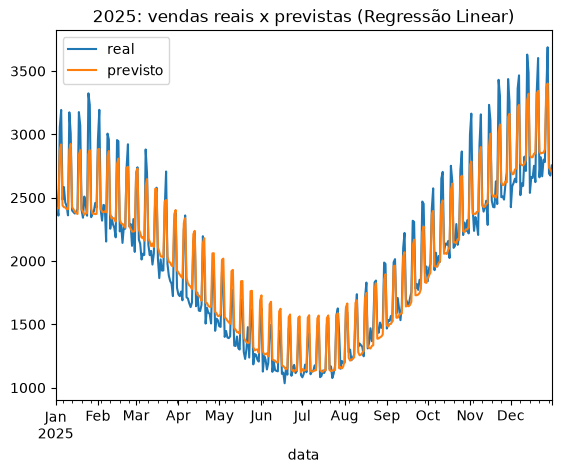

In [13]:
melhor = tabela[tabela["modelo"] != "Baseline (lag_7)"].iloc[0]["modelo"]

comparacao = pd.DataFrame({
    "data": teste["data"].values,
    "real": y_teste.values,
    "previsto": previsoes[melhor],
}).groupby("data").sum()

comparacao.plot(title=f"2025: vendas reais x previstas ({melhor})")
plt.show()

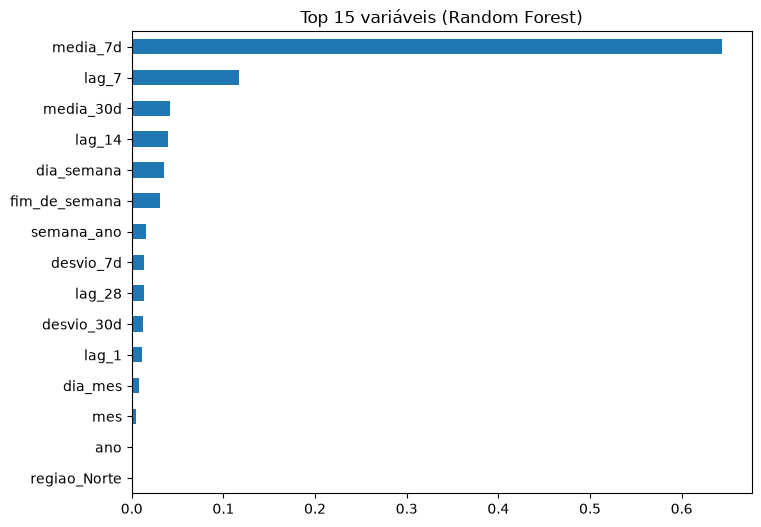

In [14]:
importancias = pd.Series(modelo_rf.feature_importances_, index=features).sort_values(ascending=False)
importancias.head(15).sort_values().plot(kind="barh", figsize=(8, 6),
                                          title="Top 15 variáveis (Random Forest)")
plt.show()

In [ ]:
import mlflow

mlflow.set_tracking_uri("http://mlflow:5000")
mlflow.set_experiment("previsao-demanda")

parametros = {
    "Baseline (lag_7)": {},
    "Regressão Linear": {},
    "Random Forest": params_rf,
    "Gradient Boosting": params_gb,
}

for r in resultados:
    with mlflow.start_run(run_name=r["modelo"]):
        mlflow.log_params(parametros[r["modelo"]])
        mlflow.log_metrics({"MAE": r["MAE"], "RMSE": r["RMSE"], "MAPE": r["MAPE_%"]})

print("Registrado no MLflow")